# 07 · Sequential testing & diagnostics — peek without lying (a *cross-cutting* layer)

**NB 07.** Unlike NB 03–06 (each a *design* for one experiment), this is a **practice that applies to
*every* experiment** regardless of design: you want to **monitor results as they accrue** and stop early
when you can — but **peeking inflates error**. We build, by hand:
1. **why peeking lies** — continuous monitoring with a fixed threshold drives the false-positive rate
   far above $\alpha$;
2. the **always-valid confidence sequence** (Waudby-Smith) — a band valid at *every* look, so you may
   peek/stop any time;
3. the **advisory auto-stop** (fires only on a CS excluding 0; min-runtime; winner's-curse caveat);
4. **SRM / A·A** — the trust gates;
5. **BH-FDR** — controlling false discoveries across the metric battery.

Then we **promote** these to `lyra/{sequential,diagnostics}.py` and **wire them across the whole
platform** — every running scorecard gets the CS + advisory, the portfolio gets FDR. Steal: Etsy peeking,
Deng–Lu proper-stopping, eBay SRM, the open-guide multiple-testing trap.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

# an experiment that accrues users day by day (binary conversion); returns the cumulative per-day series
def accrue(effect=0.0, per_day=500, days=40, p0=0.20, seed=0):
    rng = np.random.default_rng(seed); ct = cc = nt = nc = 0; out = []
    for d in range(days):
        h = per_day // 2
        ct += rng.binomial(h, p0 + effect); nt += h
        cc += rng.binomial(h, p0); nc += h
        p1, p0h = ct / nt, cc / nc
        se = math.sqrt(p1 * (1 - p1) / nt + p0h * (1 - p0h) / nc)
        out.append({"day": d + 1, "point": p1 - p0h, "se": se, "n": nt + nc})
    return out

## 1. Why peeking lies

The running test statistic $z_t=\hat\tau_t/\widehat{\mathrm{se}}_t$ is (under $H_0$) essentially a
**random walk**. A fixed-$n$ test asks "is $|z|>1.96$ at the *single* final look?" — probability
$\alpha$. **Peeking** asks "does $|z|$ *ever* cross 1.96 across many looks?" — a strict superset of
paths, so the false-positive rate is $\ge\alpha$, and by the **law of the iterated logarithm** it
$\to 1$ as you keep looking. We measure it on an **A/A** test (no real effect).

naive continuous monitoring on a TRUE NULL: false-positive rate = 30.4%  (should be 5%!)


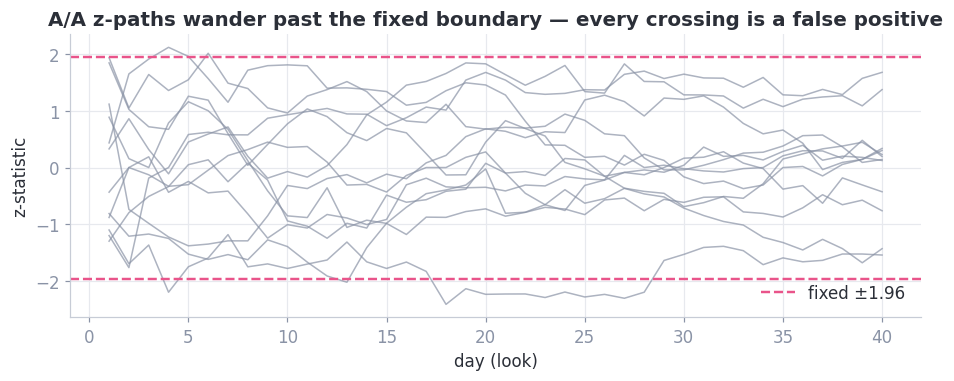

In [2]:
def peeks_fixed(series):                         # naive: stop at first |z|>1.96 (fixed threshold)
    return any(abs(r["point"]) / r["se"] > 1.959964 for r in series if r["se"] > 0)

R = 2000
fpr_naive = np.mean([peeks_fixed(accrue(0.0, seed=s)) for s in range(R)])
print(f"naive continuous monitoring on a TRUE NULL: false-positive rate = {fpr_naive:.1%}  (should be 5%!)")

# show a few A/A z-paths wandering across the fixed boundary
fig, ax = plt.subplots(figsize=(8.6, 3.6))
for s in range(12):
    series = accrue(0.0, seed=100 + s)
    z = [r["point"] / r["se"] for r in series]
    ax.plot(range(1, len(z) + 1), z, lw=1, color=GRAY, alpha=0.7)
ax.axhline(1.96, color=PINK, ls="--", lw=1.6); ax.axhline(-1.96, color=PINK, ls="--", lw=1.6, label="fixed ±1.96")
ax.set_xlabel("day (look)"); ax.set_ylabel("z-statistic"); ax.set_title("A/A z-paths wander past the fixed boundary — every crossing is a false positive")
ax.legend(); plt.tight_layout(); plt.show()

## 2. The always-valid confidence sequence

The fix is a band whose width **grows just fast enough** ($\sim\sqrt{\log n}$) that the *whole
trajectory* is covered with probability $\ge 1-\alpha$ — the **asymptotic confidence sequence**
(Waudby-Smith–Ramdas). It's the fixed-$n$ interval with $z_{1-\alpha/2}$ replaced by a time-uniform
**multiplier** $m(n)$ — the explicit *price of peeking* (always $> z$):
$$\text{CS}_n = \hat\tau_n \pm m(n)\,\widehat{\mathrm{se}}_n,\qquad
  m(n)=\sqrt{\tfrac{2(n\rho^2+1)}{n\rho^2}\,\log\tfrac{\sqrt{n\rho^2+1}}{\alpha}}.$$

confidence sequence on a TRUE NULL: false-positive rate = 0.7%  (controlled ≤ 5% despite peeking every day)
peeking tax: the multiplier at day 40 is 3.59  vs the fixed 1.96


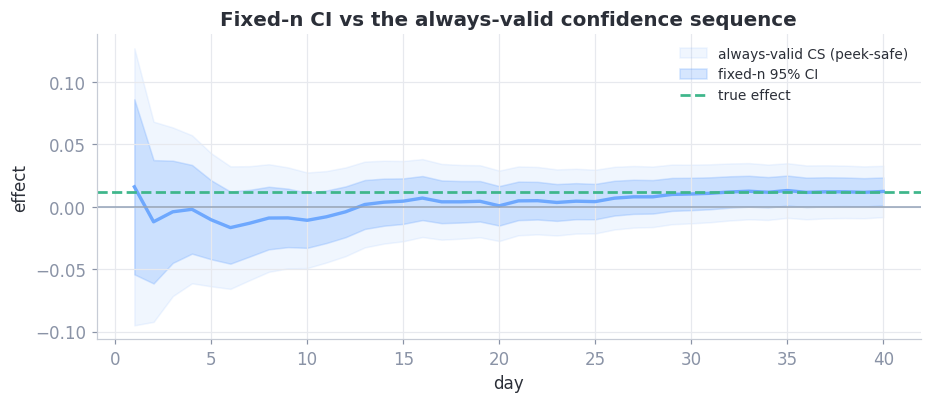

In [3]:
RHO2 = 0.05
def cs_mult(n, alpha=0.05, rho2=RHO2):
    a = n * rho2
    return math.sqrt(2 * (a + 1) / a * math.log(math.sqrt(a + 1) / alpha))

def peeks_cs(series):                            # CS excludes 0 at ANY look (peek-safe)
    return any(abs(r["point"]) > cs_mult(r["n"]) * r["se"] for r in series if r["se"] > 0)

fpr_cs = np.mean([peeks_cs(accrue(0.0, seed=s)) for s in range(R)])
print(f"confidence sequence on a TRUE NULL: false-positive rate = {fpr_cs:.1%}  (controlled ≤ 5% despite peeking every day)")
print(f"peeking tax: the multiplier at day 40 is {cs_mult(40 * 500):.2f}  vs the fixed 1.96")

# the band: fixed-n CI (narrow, lies under peeking) vs the CS (wider, peek-safe), on one A/B with a real effect
series = accrue(effect=0.012, seed=3)
d = np.array([r["day"] for r in series]); pt = np.array([r["point"] for r in series])
se = np.array([r["se"] for r in series]); m = np.array([cs_mult(r["n"]) for r in series])
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.fill_between(d, pt - m * se, pt + m * se, color=BLUE, alpha=0.10, label="always-valid CS (peek-safe)")
ax.fill_between(d, pt - 1.96 * se, pt + 1.96 * se, color=BLUE, alpha=0.28, label="fixed-n 95% CI")
ax.plot(d, pt, color=BLUE, lw=2.2); ax.axhline(0, color="#94A3B8", lw=1)
ax.axhline(0.012, color=GREEN, ls="--", lw=1.8, label="true effect")
ax.set_xlabel("day"); ax.set_ylabel("effect"); ax.set_title("Fixed-n CI vs the always-valid confidence sequence"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

The CS holds the false-positive rate at ~5% **even though we look every single day** — that's the whole
point. It costs a wider band (the multiplier), but it still shrinks, and it lets the platform offer an
honest **"safe to stop"** signal.

## 3. The advisory auto-stop (the human still decides)

When the CS **excludes 0**, recommend stopping — *advisory*, never automatic, and only after a minimum
runtime. If you stop **before the design was powered**, the winner's-curse means the **magnitude may be
inflated** (shown as a caveat; Etsy applies a haircut).

In [4]:
from lyra.sequential import confidence_sequence, advisory      # promoted below
cs = confidence_sequence(series)
stop_day = next((r["day"] for r in cs if not (r["cs_low"] <= 0 <= r["cs_high"])), None)
print(f"advisory: {advisory(cs, powered=True)['text']}")
print(f"the CS first excludes 0 on day {stop_day} (vs day 40 horizon) — an early, *valid* stop")

advisory: Keep collecting — the always-valid interval still spans 0
the CS first excludes 0 on day None (vs day 40 horizon) — an early, *valid* stop


## 4. SRM & A·A — the trust gates (run on every experiment)

**SRM** (χ² on arm sizes) catches a broken randomizer; **A·A** confirms the metric doesn't flag under no
effect. These are pre-conditions for *interpreting* any scorecard — already wired into the chassis.

In [5]:
from lyra.diagnostics import srm_chi2
print("SRM (balanced 5000/5000):", round(srm_chi2({"control": 5000, "treatment": 5000}, {"control": .5, "treatment": .5})[1], 3), "(ok)")
print("SRM (skewed 5200/4800)  :", round(srm_chi2({"control": 5200, "treatment": 4800}, {"control": .5, "treatment": .5})[1], 4), "(flags)")

SRM (balanced 5000/5000): 1.0 (ok)
SRM (skewed 5200/4800)  : 0.0001 (flags)


## 5. FDR across the metric battery

A typical experiment has many metrics. With **20 independent metrics at $\alpha=5\%$**, the chance of
**at least one** false positive is $1-0.95^{20}\approx 64\%$. **Benjamini–Hochberg** controls the
**false discovery rate** — the expected fraction of "wins" that are noise.

In [6]:
from lyra.diagnostics import bh_fdr
from scipy import stats
rng = np.random.default_rng(0)
# 20 metrics: 3 real effects, 17 null — p-values
truth_eff = np.array([0.0] * 17 + [0.25, 0.30, 0.4])
pvals = [2 * (1 - stats.norm.cdf(abs(rng.normal(e, 1)))) for e in truth_eff]
naive_sig = sum(p < 0.05 for p in pvals)
fdr = bh_fdr(pvals, alpha=0.05)
print(f"P(≥1 false positive) with 20 null metrics uncorrected = {1 - 0.95**20:.0%}")
print(f"this battery (3 real): naive p<0.05 flags {naive_sig};  BH-FDR keeps {fdr['n_significant']} (controls the false-discovery rate)")

P(≥1 false positive) with 20 null metrics uncorrected = 64%
this battery (3 real): naive p<0.05 flags 1;  BH-FDR keeps 0 (controls the false-discovery rate)


## 6. Promote → `lyra/{sequential,diagnostics}` + wire across the platform

The peek-safe layer is promoted (`cs_multiplier`, `confidence_sequence`, `advisory`; `srm_chi2`,
`bh_fdr`) and validated below against ground truth. **Unlike a design, this layer applies to *every*
experiment:** the chassis now adds an **always-valid CS + advisory stop to every running scorecard**, and
a **portfolio FDR** across the registry — best practice, uniformly.

In [7]:
from lyra.sequential import cs_multiplier
# certify the CS is peek-safe and the fixed test is not (Monte-Carlo, the platform's gate)
print(f"promoted CS — continuous-monitoring false-positive rate on A/A: "
      f"{np.mean([any(abs(r['point'])>cs_multiplier(r['n'])*r['se'] for r in accrue(0.0,seed=s)) for s in range(800)]):.1%}  (≤5% ✓)")
print(f"               vs naive fixed-threshold peeking:                 "
      f"{np.mean([peeks_fixed(accrue(0.0,seed=s)) for s in range(800)]):.1%}  (broken)")

promoted CS — continuous-monitoring false-positive rate on A/A: 0.5%  (≤5% ✓)
               vs naive fixed-threshold peeking:                 29.8%  (broken)


✅ **Promoted** (covered by `tests/test_sequential.py`). **Next:** the chassis wires the CS + advisory
onto every running scorecard and FDR into the portfolio view — then **NB 08 — power & decisions**
(the DRAFT power-gate + the decision rule; recycle the experiment-design lab).